In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [2]:
df = pd.read_csv('Data/1723a.dat', header=None)

In [3]:
print(len(df))

1277488


[612.51477782   0.80532952]
[600.33333333 382.         285.66666667 242.33333333 190.66666667
 175.33333333 161.33333333 163.66666667]
[502.58 332.28 257.14 223.34 183.04 171.08 160.16 161.98]


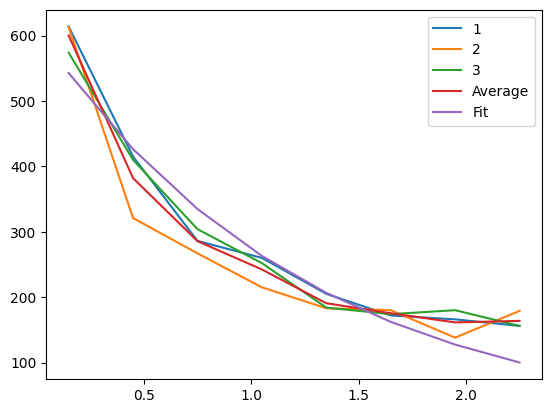

In [32]:
ys1 = np.array([614, 415, 286, 260, 205, 172, 166,156])
ys2 = np.array([613, 321, 267, 215, 183, 180, 138, 179])
ys3 = np.array([574, 410, 304, 252, 184, 174, 180, 156])
xs1 = np.array([1.5, 4.5, 7.5, 10.5, 13.5, 16.5, 19.5, 22.5])
xs1 /= 10
plt.plot(xs1, ys1, label='1')
plt.plot(xs1, ys2, label='2')
plt.plot(xs1, ys3, label='3')
plt.plot(xs1, (ys1 + ys2 + ys3) / 3, label='Average')
def exp(x, a, b, c):
    return a * np.exp(-b * x) + c
def exp2(x, a, b):
    return a * np.exp(-b * x)
popt, pcov = curve_fit(exp2, xs1, (ys1 + ys2 + ys3) / 3, p0=(500, 0.8))
plt.plot(xs1, exp2(xs1, *popt), label='Fit')
print(popt)
print((ys1 + ys2 + ys3) / 3)
print(((ys1 + ys2 + ys3) / 3 -156)* 0.78 + 156)
plt.legend()
plt.show()


[3.95738260e+00 8.83000004e-01 5.80733781e-09]


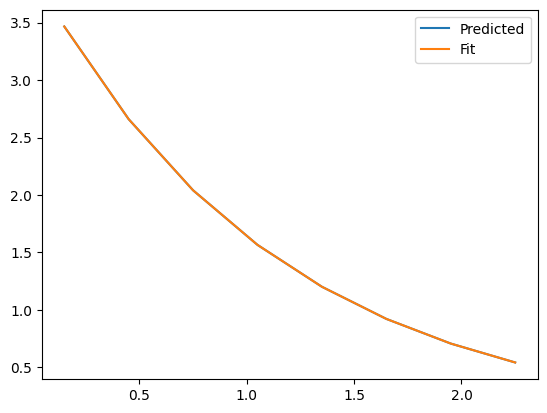

In [20]:
def integralexp(bL, bR, mu):
    return (-1/mu*np.exp(-mu*bR) + 1/mu*np.exp(-mu*bL))
predx = []
for x in xs1:
    predx.append(integralexp(x - 1.5, x + 1.5, 0.883))
plt.plot(xs1, predx, label='Predicted')
popt, pcov = curve_fit(exp, xs1, predx)
print(popt)
plt.plot(xs1, exp(xs1, *popt), label='Fit')
plt.legend()
plt.show()